In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu128
!pip install opencv-python pillow scikit-learn matplotlib numpy
!pip install tensorflow
!pip install git+https://github.com/facebookresearch/segment-anything.git
!pip install albumentations --user

Looking in indexes: https://download.pytorch.org/whl/cu128
  Cloning https://github.com/facebookresearch/segment-anything.git to C:\Users\Florin\AppData\Local\Temp\pip-req-build-knxzkzwq
  Resolved https://github.com/facebookresearch/segment-anything.git to commit dca509fe793f601edb92606367a655c15ac00fdf
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/facebookresearch/segment-anything.git 'C:\Users\Florin\AppData\Local\Temp\pip-req-build-knxzkzwq'


   ---------------------------------------- 0.0/40.1 MB ? eta -:--:--
   -------- ------------------------------- 8.1/40.1 MB 40.0 MB/s eta 0:00:01
   ---------------------- ----------------- 22.5/40.1 MB 54.0 MB/s eta 0:00:01
   ---------------------------------- ----- 34.3/40.1 MB 54.6 MB/s eta 0:00:01
   ---------------------------------------- 40.1/40.1 MB 50.7 MB/s  0:00:00

   ---------------- ----------------------- 2/5 [opencv-python-headless]



ERROR: Could not install packages due to an OSError: [WinError 5] Access is denied: 'C:\\Users\\Florin\\miniconda3\\Lib\\site-packages\\cv2\\cv2.pyd'
Consider using the `--user` option or check the permissions.



In [4]:
from matplotlib import pyplot as plt
from matplotlib.colors import ListedColormap
import os
from os import listdir
from os.path import isfile, join
import numpy as np
from os import listdir
from os.path import isfile, join

In [4]:
!curl -L -o apple-rotting-segmentation-problem-in-the-wild.zip https://www.kaggle.com/api/v1/datasets/download/sergeynesteruk/apple-rotting-segmentation-problem-in-the-wild

  % Total    % Received % Xferd  Average Speed  Time    Time    Time   Current
                                 Dload  Upload  Total   Spent   Left   Speed

  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0
  0      0   0      0   0      0      0      0                              0

  0      0   0      0   0      0      0      0                              0
  0  2.31G   0 449.2k   0      0 369.0k      0 1:49:45   00:01 1:49:44 449.2k
  0  2.31G   0 18.00M   0      0  7.95M      0   04:58   00:02   04:56  8.80M
  1  2.31G   1 41.79M   0      0 12.65M      0   03:07   00:03   03:04 13.55M
  2  2.31G   2 66.00M   0      0 15.33M      0   02:34   00:04   02:30 16.15M
  4  2.31G   4 96.35M   0      0 18.16M      0   02:10   00:05   02:05 18.94M
  5  2.31G   5 123.7M   0      0 19.52M      0   02:01   00:06   01:55 24.08M
  6  2.31G   6 146.5M   0      0 19.91M      0   01:59   00:07

In [6]:
import zipfile
with zipfile.ZipFile("apple-rotting-segmentation-problem-in-the-wild.zip", 'r') as z:
    z.extractall("dataset")

In [2]:
!dir

 Volume in drive C has no label.
 Volume Serial Number is 80B7-E3C5

 Directory of c:\Users\Florin\Downloads\AI_model

06/26/2026  06:57 AM    <DIR>          .
06/26/2026  06:58 AM    <DIR>          ..
06/26/2026  06:55 AM    <DIR>          dataset
06/26/2026  06:59 AM            76,476 sam_apple_spoilage (1).ipynb
               1 File(s)         76,476 bytes
               3 Dir(s)  79,717,261,312 bytes free


In [6]:
train_path = 'dataset/apples_segmentation/apples_segmentation/max_data/train/'
backgrounds_path = 'dataset/apples_segmentation/apples_segmentation/Sk_background/'
wild_test_path = 'dataset/test_wild/test_wild/'
#/content/kaggle.json
train_images = [join(train_path, f) for f in listdir(train_path) if isfile(join(train_path, f)) and f.split('.')[-1].lower() == 'jpg']
backgrounds_images = [join(backgrounds_path, f) for f in listdir(backgrounds_path) if isfile(join(backgrounds_path, f)) and f.split('.')[-1].lower() == 'jpg']
wild_test_images = [join(wild_test_path, f) for f in listdir(wild_test_path) if isfile(join(wild_test_path, f)) and f.split('.')[-1].lower() == 'jpg']

In [7]:
import os
import numpy as np
import torch
import torchvision
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import tensorflow as tf
from tensorflow.keras import layers, models
from segment_anything import sam_model_registry, SamPredictor

In [17]:
print("=== Setting up configuration ===")
class Config:
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    SAM_CHECKPOINT = "sam_vit_b_01ec64.pth"
    MODEL_TYPE = "vit_b"
    IMG_SIZE = 1024
    BATCH_SIZE = 4
    EPOCHS = 50
    LR = 1e-4
    NUM_CLASSES = 3
    DATA_PATH = "dataset/apples_segmentation/apples_segmentation/max_data/"

config = Config()
print(f"Configuration set. Device: {config.DEVICE}, Image size: {config.IMG_SIZE}")

=== Setting up configuration ===
Configuration set. Device: cuda, Image size: 1024


In [ ]:
import albumentations as A
from albumentations.pytorch import ToTensorV2

train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.3),
    A.RandomRotate90(p=0.5),
    A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
    A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, p=0.3),
    A.GaussNoise(p=0.2),
])

print("\n=== Preparing dataset ===")
class AppleDataset(Dataset):
    def __init__(self, image_paths, transform=None):
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = img_path.replace('.jpg', '.png').replace('obj', 'msk')

        image = cv2.imread(img_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        image = cv2.resize(image, (config.IMG_SIZE, config.IMG_SIZE))

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (config.IMG_SIZE, config.IMG_SIZE), interpolation=cv2.INTER_NEAREST)

        if self.transform:
            augmented = self.transform(image=image, mask=mask)
            image = augmented['image']
            mask = augmented['mask']

        processed_mask = np.zeros((config.IMG_SIZE, config.IMG_SIZE, config.NUM_CLASSES), dtype=np.float32)
        processed_mask[:, :, 0] = (mask == 0).astype(np.float32)
        processed_mask[:, :, 1] = np.logical_or.reduce((mask == 1, mask == 2, mask == 3)).astype(np.float32)
        processed_mask[:, :, 2] = (mask == 4).astype(np.float32)

        image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
        processed_mask = torch.from_numpy(processed_mask).permute(2, 0, 1).float()

        return image, processed_mask

def prepare_data_paths(data_dir):
    print(data_dir)
    print(f"Scanning for images in {data_dir}...")
    image_paths = []
    for root, _, files in os.walk(data_dir):
        print(f"Checking directory: {root}, found {len(files)} files")
        for file in files:
            if file.endswith('.jpg') and 'obj' in file:
                full_path = os.path.join(root, file)
                mask_path = full_path.replace('.jpg', '.png').replace('obj', 'msk')
                if os.path.exists(mask_path):
                    image_paths.append(full_path)
    print(f"Found {len(image_paths)} valid image-mask pairs")
    return image_paths

image_paths = prepare_data_paths(config.DATA_PATH)
train_paths, val_paths = train_test_split(image_paths, test_size=0.2, random_state=42)

train_dataset = AppleDataset(train_paths)
val_dataset = AppleDataset(val_paths)

pythontrain_loader = DataLoader(
    train_dataset,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=4,        # ← încarcă datele în paralel
    pin_memory=True,      # ← transfer mai rapid CPU→GPU
    prefetch_factor=2     # ← prefetch batches
)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE)

print(f"\n=== Data loaded ===")
print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")
print(f"Batch size: {config.BATCH_SIZE}")

c:\Users\Florin\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm



=== Preparing dataset ===
dataset/apples_segmentation/apples_segmentation/max_data/
Scanning for images in dataset/apples_segmentation/apples_segmentation/max_data/...
Checking directory: dataset/apples_segmentation/apples_segmentation/max_data/, found 0 files
Checking directory: dataset/apples_segmentation/apples_segmentation/max_data/test, found 2552 files
Checking directory: dataset/apples_segmentation/apples_segmentation/max_data/train, found 5916 files
Found 4234 valid image-mask pairs

=== Data loaded ===
Training samples: 3387
Validation samples: 847
Batch size: 4


In [28]:
print("\n=== Loading SAM model ===")
sam = sam_model_registry[config.MODEL_TYPE](checkpoint=config.SAM_CHECKPOINT)
sam.to(config.DEVICE)
print(f"SAM {config.MODEL_TYPE} loaded on {config.DEVICE}")

for param in sam.image_encoder.parameters():
    param.requires_grad = False
print("Frozen SAM image encoder parameters")

class SpoilageHead(torch.nn.Module):
    def __init__(self, input_dim=256, num_classes=3):
        super().__init__()
        self.conv1 = torch.nn.Conv2d(input_dim, 128, kernel_size=3, padding=1)
        self.bn1 = torch.nn.BatchNorm2d(128)
        self.conv2 = torch.nn.Conv2d(128, 64, kernel_size=3, padding=1)
        self.bn2 = torch.nn.BatchNorm2d(64)
        self.conv3 = torch.nn.Conv2d(64, num_classes, kernel_size=1)
        self.upsample = torch.nn.Upsample(scale_factor=4, mode='bilinear', align_corners=True)
        self.relu = torch.nn.ReLU()

    def forward(self, x):
        x = self.relu(self.bn1(self.conv1(x)))
        x = self.relu(self.bn2(self.conv2(x)))
        x = self.conv3(x)
        x = torch.nn.functional.interpolate(
            x, size=(config.IMG_SIZE, config.IMG_SIZE), mode='bilinear', align_corners=True
        )
        return x


class FineTunedSAM(torch.nn.Module):
    def __init__(self, sam_model, num_classes=3):
        super().__init__()
        self.sam = sam_model
        self.spoilage_head = SpoilageHead(num_classes=num_classes)

    def forward(self, x):
        with torch.no_grad():
            image_embeddings = self.sam.image_encoder(x)  # this is usually [B, 256, 64, 64]

        # Pass directly to your head
        output = self.spoilage_head(image_embeddings)
        return output

model = FineTunedSAM(sam, num_classes=config.NUM_CLASSES)
model.to(config.DEVICE)
print("\n=== Model architecture created ===")
print("Added custom spoilage detection head to SAM")

class FocalTverskyLoss(torch.nn.Module):
    def __init__(self, alpha=0.7, beta=0.3, gamma=1.5, smooth=1e-6):
        super().__init__()
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = preds.contiguous().view(-1)
        targets = targets.contiguous().view(-1)
        tp = (preds * targets).sum()
        fp = (preds * (1 - targets)).sum()
        fn = ((1 - preds) * targets).sum()
        tversky = (tp + self.smooth) / (tp + self.alpha * fn + self.beta * fp + self.smooth)
        return (1 - tversky) ** self.gamma

class CombinedLoss(torch.nn.Module):
    def __init__(self, class_weights=None):
        super().__init__()
        self.ce_loss = torch.nn.CrossEntropyLoss(weight=class_weights)
        self.ft_loss = FocalTverskyLoss()

    def forward(self, preds, targets):
        ce = self.ce_loss(preds, torch.argmax(targets, dim=1))
        ft = 0
        for i in range(targets.shape[1]):
            ft += self.ft_loss(torch.sigmoid(preds[:, i]), targets[:, i])
        ft /= targets.shape[1]
        return ce + ft

def calculate_class_weights(dataset):
    print("\n=== Calculating class weights ===")
    class_counts = np.zeros(config.NUM_CLASSES)
    sample_count = min(500, len(dataset))
    print(f"Using {sample_count} samples to estimate class weights...")

    for i in range(sample_count):
        _, mask = dataset[i]
        class_idx = torch.argmax(mask, dim=0)
        counts = np.bincount(class_idx.flatten(), minlength=config.NUM_CLASSES)
        class_counts += counts

    class_weights = 1.0 / (class_counts + 1e-6)
    class_weights = class_weights / class_weights.sum() * config.NUM_CLASSES
    weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(config.DEVICE)
    print(f"Class weights calculated: {weights_tensor.cpu().numpy()}")
    return weights_tensor

class_weights = calculate_class_weights(train_dataset)

optimizer = torch.optim.Adam(model.parameters(), lr=config.LR)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

criterion = CombinedLoss(class_weights=class_weights)


=== Loading SAM model ===
SAM vit_b loaded on cuda
Frozen SAM image encoder parameters

=== Model architecture created ===
Added custom spoilage detection head to SAM

=== Calculating class weights ===
Using 500 samples to estimate class weights...
Class weights calculated: [0.8981634 1.4336683 0.6681683]


In [32]:
from torch.amp import autocast, GradScaler

print("\n=== Starting training ===")
print(f"Will train for {config.EPOCHS} epochs")
print(f"Learning rate: {config.LR}")
print(f"Using combined loss (CE + Focal Tversky)")

scaler = GradScaler("cuda")

# LR Scheduler
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=5
)

def train_epoch(model, dataloader, optimizer, criterion):
    model.train()
    total_loss = 0.0
    for batch_idx, (images, masks) in enumerate(dataloader):
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)

        optimizer.zero_grad()

        with autocast("cuda"):
            outputs = model(images)
            loss = criterion(outputs, masks)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()

        if batch_idx % 10 == 0:
            print(f"  Batch {batch_idx}/{len(dataloader)} - Loss: {loss.item():.4f}")

    return total_loss / len(dataloader)


def validate_epoch(model, dataloader, criterion):
    model.eval()
    total_loss = 0.0
    all_ious = [0.0, 0.0, 0.0]
    num_batches = 0

    with torch.no_grad():
        for images, masks in dataloader:
            images = images.to(config.DEVICE)
            masks = masks.to(config.DEVICE)

            with autocast("cuda"):
                outputs = model(images)
                loss = criterion(outputs, masks)

            total_loss += loss.item()

            # IoU per batch
            preds = torch.argmax(outputs, dim=1)
            targets = torch.argmax(masks, dim=1)
            for cls in range(config.NUM_CLASSES):
                intersection = ((preds == cls) & (targets == cls)).sum().float()
                union = ((preds == cls) | (targets == cls)).sum().float()
                all_ious[cls] += (intersection + 1e-6) / (union + 1e-6)
            num_batches += 1

    avg_ious = [iou / num_batches for iou in all_ious]
    return total_loss / num_batches, avg_ious


# Early stopping
patience = 10
epochs_no_improve = 0

best_val_loss = float('inf')
train_losses = []
val_losses = []

for epoch in range(config.EPOCHS):
    print(f"\nEpoch {epoch+1}/{config.EPOCHS}")
    print("Training...")
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    print("Validating...")
    val_loss, val_ious = validate_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} complete")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"IoU — Background: {val_ious[0]:.3f} | Spoiled: {val_ious[1]:.3f} | Fresh: {val_ious[2]:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        # Salveaza best (suprascris mereu — modelul cel mai bun overall)
        torch.save(model.state_dict(), "best_apple_spoilage_sam.pth")
        # Salveaza si cu numarul epocii (nu se suprascrie)
        torch.save(model.state_dict(), f"checkpoint_epoch_{epoch+1}_loss_{val_loss:.4f}.pth")
        print("*** New best model saved ***")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

print("\n=== Training complete ===")


=== Starting training ===
Will train for 50 epochs
Learning rate: 0.0001
Using combined loss (CE + Focal Tversky)

Epoch 1/50
Training...
  Batch 0/847 - Loss: 0.4250
  Batch 10/847 - Loss: 0.5963
  Batch 20/847 - Loss: 0.5234
  Batch 30/847 - Loss: 0.3425
  Batch 40/847 - Loss: 0.4997
  Batch 50/847 - Loss: 0.5337
  Batch 60/847 - Loss: 0.3686
  Batch 70/847 - Loss: 0.6384
  Batch 80/847 - Loss: 0.3261
  Batch 90/847 - Loss: 0.4416
  Batch 100/847 - Loss: 0.5300
  Batch 110/847 - Loss: 0.3195
  Batch 120/847 - Loss: 0.3058
  Batch 130/847 - Loss: 0.5003
  Batch 140/847 - Loss: 0.6753
  Batch 150/847 - Loss: 0.2871
  Batch 160/847 - Loss: 0.5363
  Batch 170/847 - Loss: 0.5254
  Batch 180/847 - Loss: 0.3419
  Batch 190/847 - Loss: 0.3536
  Batch 200/847 - Loss: 0.6764
  Batch 210/847 - Loss: 0.6336
  Batch 220/847 - Loss: 0.5828
  Batch 230/847 - Loss: 0.4152
  Batch 240/847 - Loss: 0.6698
  Batch 250/847 - Loss: 0.7613
  Batch 260/847 - Loss: 0.3332
  Batch 270/847 - Loss: 0.5235
  Ba

Plotting training curves...


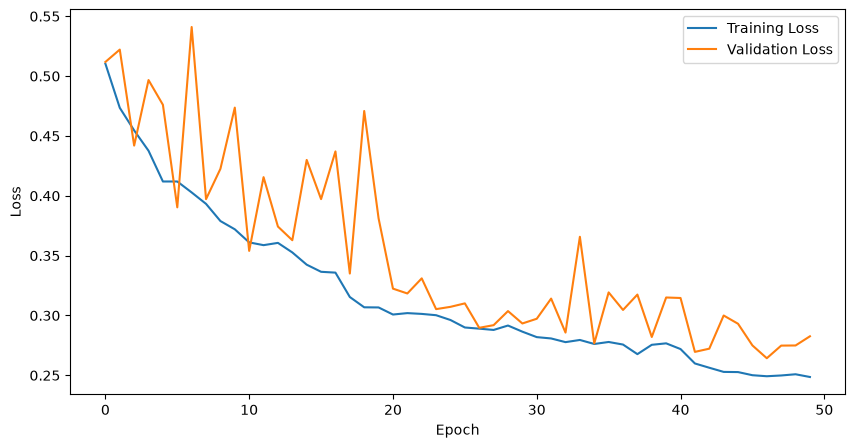


Saving final model...
=== All done! ===


In [33]:
print("Plotting training curves...")
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

print("\nSaving final model...")
torch.save({
    'model_state_dict': model.state_dict(),
    'class_weights': class_weights,
    'config': vars(config)
}, "apple_spoilage_sam_final.pth")

print("=== All done! ===")

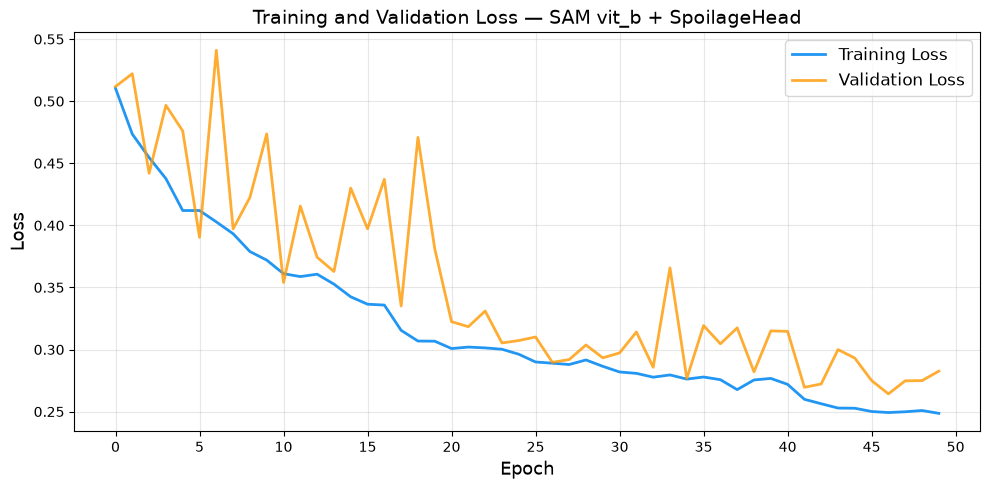

Saved to loss_curves.png


In [34]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(train_losses, label='Training Loss', color='#2196F3', linewidth=2)
ax.plot(val_losses, label='Validation Loss', color='#FF9800', linewidth=2, alpha=0.8)
ax.set_xlabel('Epoch', fontsize=13)
ax.set_ylabel('Loss', fontsize=13)
ax.set_title('Training and Validation Loss — SAM vit_b + SpoilageHead', fontsize=14)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_locator(ticker.MultipleLocator(5))
plt.tight_layout()
plt.savefig('loss_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to loss_curves.png")

In [35]:
# Calculeaza IoU final pe tot validation set-ul
model.load_state_dict(torch.load("best_apple_spoilage_sam.pth", map_location=config.DEVICE))
model.eval()

all_ious = [0.0, 0.0, 0.0]
num_batches = 0

with torch.no_grad():
    for images, masks in val_loader:
        images = images.to(config.DEVICE)
        masks = masks.to(config.DEVICE)
        outputs = model(images)
        
        preds = torch.argmax(outputs, dim=1)
        targets = torch.argmax(masks, dim=1)
        for cls in range(config.NUM_CLASSES):
            intersection = ((preds == cls) & (targets == cls)).sum().float()
            union = ((preds == cls) | (targets == cls)).sum().float()
            all_ious[cls] += (intersection + 1e-6) / (union + 1e-6)
        num_batches += 1

avg_ious = [iou / num_batches for iou in all_ious]
class_names = ['Background', 'Spoiled', 'Fresh']
mean_iou = sum(avg_ious) / len(avg_ious)

print("=== Final IoU Results (Best Model) ===")
for name, iou in zip(class_names, avg_ious):
    print(f"  {name}: {iou:.4f}")
print(f"  Mean IoU: {mean_iou:.4f}")

=== Final IoU Results (Best Model) ===
  Background: 0.9599
  Spoiled: 0.6927
  Fresh: 0.8404
  Mean IoU: 0.8310


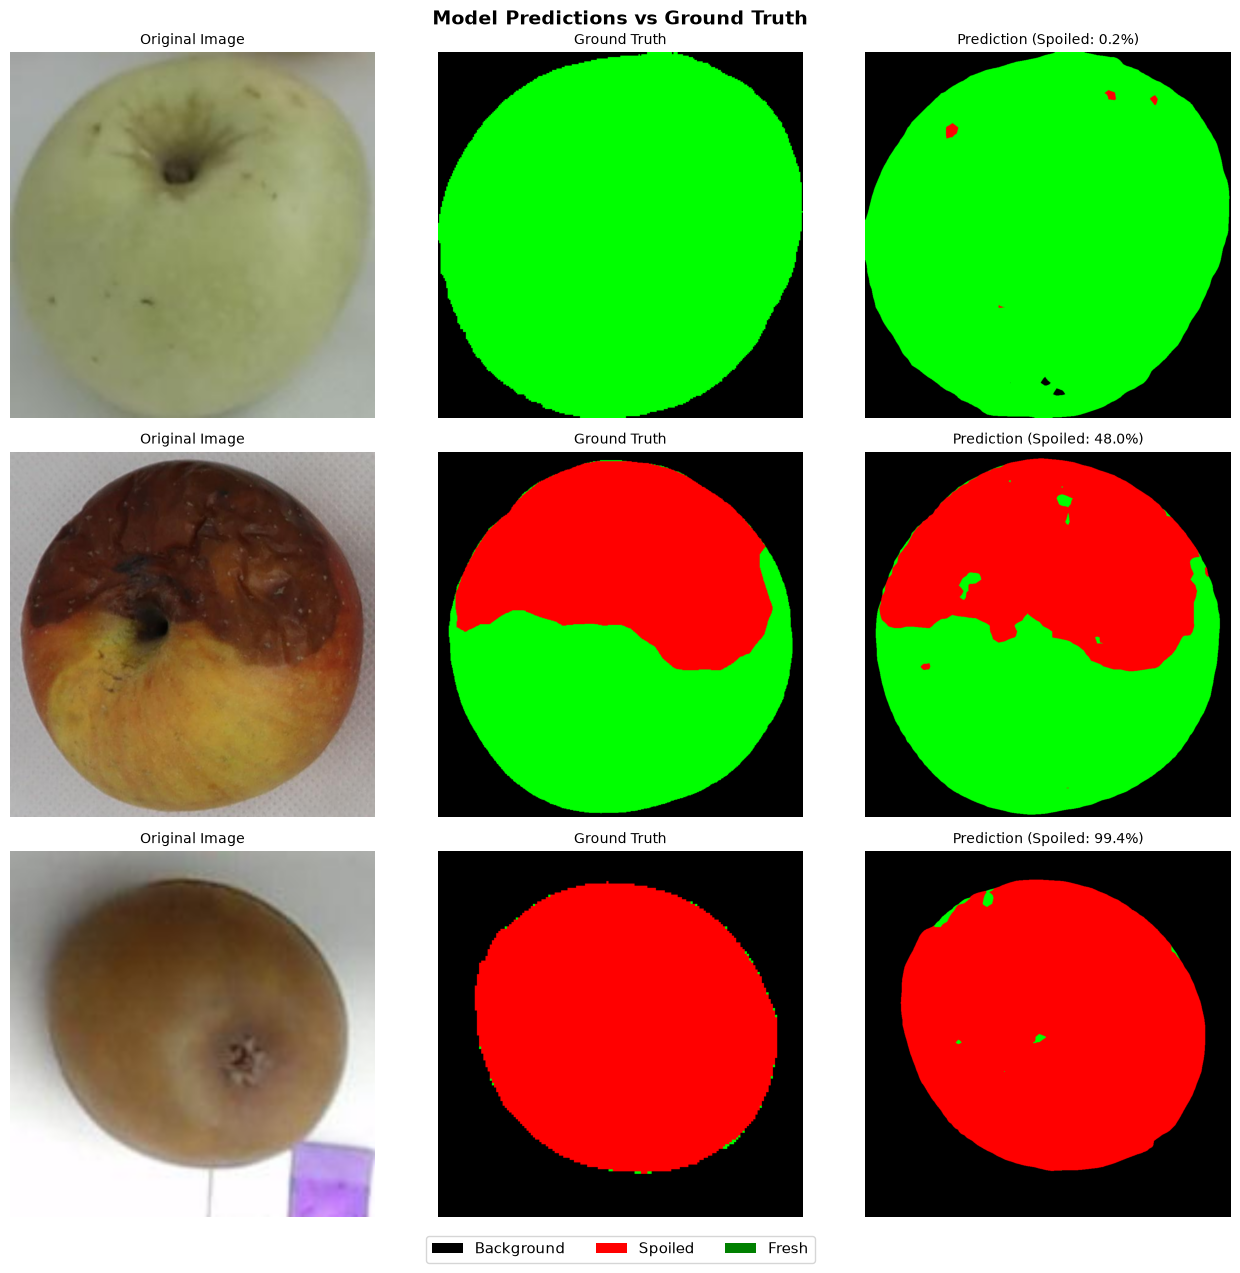

In [36]:
import random

model.eval()
fig, axes = plt.subplots(3, 3, figsize=(13, 13))
colors = [[0,0,0], [1,0,0], [0,1,0]]  # background, spoiled, fresh
cmap = ListedColormap(colors)

sample_indices = random.sample(range(len(val_dataset)), 3)

for row, idx in enumerate(sample_indices):
    image, mask = val_dataset[idx]
    
    with torch.no_grad():
        output = model(image.unsqueeze(0).to(config.DEVICE))
    
    pred = torch.argmax(output.squeeze(0), dim=0).cpu().numpy()
    gt = torch.argmax(mask, dim=0).numpy()
    img_np = image.permute(1, 2, 0).numpy()
    
    # Original
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title('Original Image', fontsize=10)
    axes[row, 0].axis('off')
    
    # Ground truth
    axes[row, 1].imshow(gt, cmap=cmap, vmin=0, vmax=2)
    axes[row, 1].set_title('Ground Truth', fontsize=10)
    axes[row, 1].axis('off')
    
    # Prediction
    axes[row, 2].imshow(pred, cmap=cmap, vmin=0, vmax=2)
    spoiled_pct = (pred == 1).sum() / (pred > 0).sum() * 100 if (pred > 0).sum() > 0 else 0
    axes[row, 2].set_title(f'Prediction (Spoiled: {spoiled_pct:.1f}%)', fontsize=10)
    axes[row, 2].axis('off')

# Legenda
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='black', label='Background'),
    Patch(facecolor='red', label='Spoiled'),
    Patch(facecolor='green', label='Fresh')
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3, fontsize=11, 
           bbox_to_anchor=(0.5, 0.01))
plt.suptitle('Model Predictions vs Ground Truth', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.04, 1, 1])
plt.savefig('predictions_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

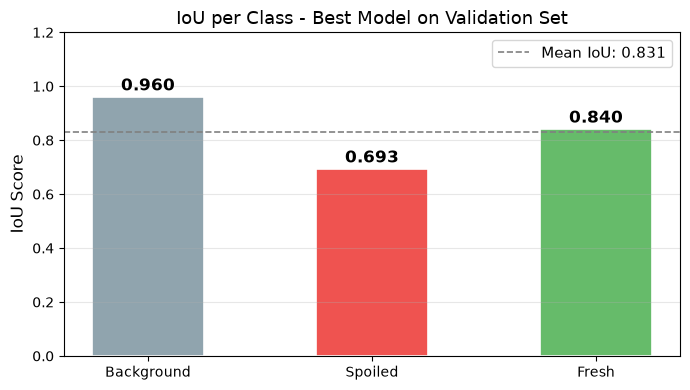

In [42]:
fig, ax = plt.subplots(figsize=(7, 4))
colors = ['#90A4AE', '#EF5350', '#66BB6A']

avg_ious = [x.cpu().item() if hasattr(x, 'cpu') else float(x) for x in avg_ious]
mean_iou = float(sum(avg_ious) / len(avg_ious))

bars = ax.bar(class_names, avg_ious, color=colors, width=0.5, edgecolor='white', linewidth=1.2)

for bar, iou in zip(bars, avg_ious):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{iou:.3f}', ha='center', va='bottom', fontsize=12, fontweight='bold')

ax.axhline(y=mean_iou, color='gray', linestyle='--', linewidth=1.2, label=f'Mean IoU: {mean_iou:.3f}')
ax.set_ylim(0, 1.2)
ax.set_ylabel('IoU Score', fontsize=12)
ax.set_title('IoU per Class - Best Model on Validation Set', fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('iou_results.png', dpi=200, bbox_inches='tight')
plt.show()

In [ ]:
# === CONTINUE TRAINING FROM CHECKPOINT ===

# Incarca cel mai bun model salvat
checkpoint_path = "best_apple_spoilage_sam.pth"
model.load_state_dict(torch.load(checkpoint_path, map_location=config.DEVICE))
print(f"Loaded checkpoint from {checkpoint_path}")

# Configuratie pentru continuare
EXTRA_EPOCHS = 30  # cate epoci in plus vrei
patience = 10
epochs_no_improve = 0
best_val_loss = float('inf')  # reseteaza - va fi suprascris dupa prima validare

# Verifica val loss curent inainte sa continuam
print("Checking current val loss...")
current_val_loss, current_ious = validate_epoch(model, val_loader, criterion)
best_val_loss = current_val_loss
print(f"Current Val Loss: {current_val_loss:.4f}")
print(f"IoU — Background: {current_ious[0]:.3f} | Spoiled: {current_ious[1]:.3f} | Fresh: {current_ious[2]:.3f}")

# Continua listele de losses de unde am ramas
# (train_losses si val_losses sunt deja in memorie din training-ul anterior)
# Daca ai restartat kernel-ul, initializeaza-le gol:
# train_losses = []
# val_losses = []

print(f"\n=== Continuing training for {EXTRA_EPOCHS} more epochs ===")

for epoch in range(EXTRA_EPOCHS):
    print(f"\nEpoch {epoch+1}/{EXTRA_EPOCHS}")
    print("Training...")
    train_loss = train_epoch(model, train_loader, optimizer, criterion)
    print("Validating...")
    val_loss, val_ious = validate_epoch(model, val_loader, criterion)

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1} complete")
    print(f"Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")
    print(f"IoU — Background: {val_ious[0]:.3f} | Spoiled: {val_ious[1]:.3f} | Fresh: {val_ious[2]:.3f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), "best_apple_spoilage_sam.pth")
        torch.save(model.state_dict(), f"checkpoint_epoch_{50+epoch+1}_loss_{val_loss:.4f}.pth")
        print("*** New best model saved ***")
    else:
        epochs_no_improve += 1
        print(f"No improvement for {epochs_no_improve}/{patience} epochs")
        if epochs_no_improve >= patience:
            print(f"Early stopping triggered at epoch {50+epoch+1}")
            break

print("\n=== Continued training complete ===")

# Plotează toate losses (inclusiv cele din training-ul anterior)
plt.figure(figsize=(12, 5))
plt.plot(train_losses, label='Training Loss')
plt.plot(val_losses, label='Validation Loss')
plt.axvline(x=49, color='gray', linestyle='--', label='Continue point')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss (full)')
plt.legend()
plt.show()

In [43]:
import json

# Salveaza losses
with open("losses.json", "w") as f:
    json.dump({"train": train_losses, "val": val_losses}, f)
print(f"Saved losses.json — {len(train_losses)} epochs")

# Salveaza avg_ious (valorile finale de pe validation set)
avg_ious_clean = [x.cpu().item() if hasattr(x, 'cpu') else float(x) for x in avg_ious]
with open("avg_ious.json", "w") as f:
    json.dump(avg_ious_clean, f)
print(f"Saved avg_ious.json — {avg_ious_clean}")

Saved losses.json — 50 epochs
Saved avg_ious.json — [0.9598879218101501, 0.6927270293235779, 0.8403680324554443]


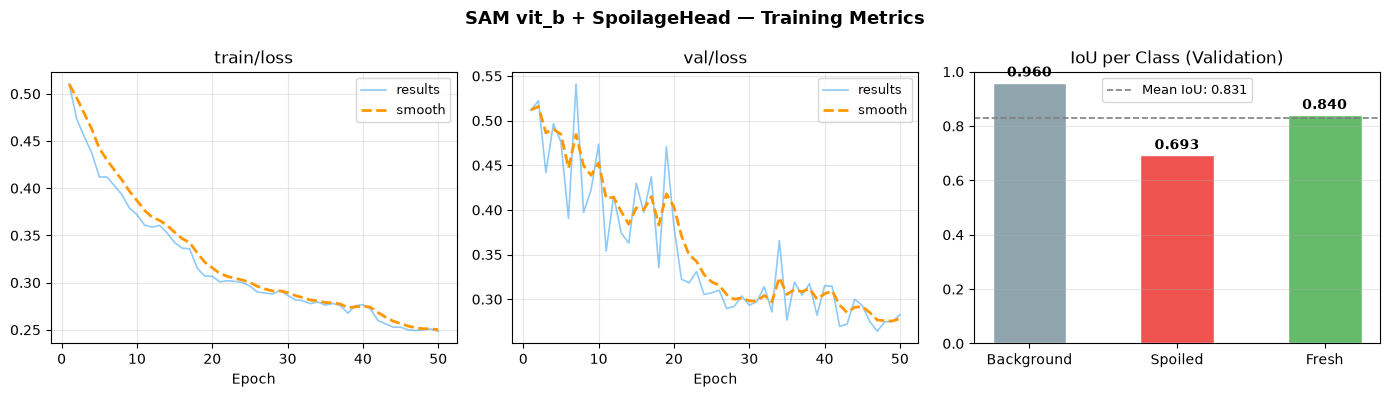

Saved training_metrics.png


In [44]:
import json

# Incarca datele salvate
with open("losses.json", "r") as f:
    data = json.load(f)
train_losses = data["train"]
val_losses = data["val"]

with open("avg_ious.json", "r") as f:
    avg_ious = json.load(f)

# Daca nu ai avg_ious per epoca ci doar finalul, folosim doar loss curves
# Grafic in stilul referintei — 2 randuri, multiple subploturi
import matplotlib.pyplot as plt
import numpy as np

epochs = list(range(1, len(train_losses) + 1))

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('SAM vit_b + SpoilageHead — Training Metrics', fontsize=13, fontweight='bold')

# Smooth helper
def smooth(y, factor=0.6):
    smoothed = []
    last = y[0]
    for val in y:
        last = last * factor + val * (1 - factor)
        smoothed.append(last)
    return smoothed

# Plot 1 — Train Loss
axes[0].plot(epochs, train_losses, color='#2196F3', linewidth=1.2, alpha=0.5, label='results')
axes[0].plot(epochs, smooth(train_losses), color='#FF9800', linewidth=2,
             linestyle='--', label='smooth')
axes[0].set_title('train/loss')
axes[0].set_xlabel('Epoch')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

# Plot 2 — Val Loss
axes[1].plot(epochs, val_losses, color='#2196F3', linewidth=1.2, alpha=0.5, label='results')
axes[1].plot(epochs, smooth(val_losses), color='#FF9800', linewidth=2,
             linestyle='--', label='smooth')
axes[1].set_title('val/loss')
axes[1].set_xlabel('Epoch')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Plot 3 — IoU bar (valorile finale)
class_names = ['Background', 'Spoiled', 'Fresh']
colors_bar = ['#90A4AE', '#EF5350', '#66BB6A']
avg_ious_clean = [float(x) for x in avg_ious]
mean_iou = sum(avg_ious_clean) / len(avg_ious_clean)
bars = axes[2].bar(class_names, avg_ious_clean, color=colors_bar, width=0.5, edgecolor='white')
for bar, iou in zip(bars, avg_ious_clean):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                f'{iou:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
axes[2].axhline(y=mean_iou, color='gray', linestyle='--', linewidth=1.2,
               label=f'Mean IoU: {mean_iou:.3f}')
axes[2].set_ylim(0, 1.0)
axes[2].set_title('IoU per Class (Validation)')
axes[2].legend(fontsize=9)
axes[2].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('training_metrics.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()
print("Saved training_metrics.png")